 loading dataset

In [1]:
import yfinance as yf

df = yf.download("MSFT", period="max")

df.to_csv("MSFT.csv")

[*********************100%***********************]  1 of 1 completed


importing liberies

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
1986-03-13,0.059125,0.061765,0.053847,0.053847,1031788800
1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000
1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200
1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400
1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400


In [4]:
df.shape

(10150, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10150 entries, 1986-03-13 to 2026-06-26
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   10149 non-null  float64
 1   (High, MSFT)    10149 non-null  float64
 2   (Low, MSFT)     10149 non-null  float64
 3   (Open, MSFT)    10149 non-null  float64
 4   (Volume, MSFT)  10150 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 475.8 KB


In [6]:
df.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

In [7]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,10149.000000,10149.000000,10149.000000,10149.000000,1.015000e+04
mean,70.166895,70.843024,69.443582,70.160957,5.531524e+07
std,119.652134,120.727085,118.502171,119.664573,3.792884e+07
min,0.054902,0.055958,0.053847,0.053847,2.304000e+06
25%,3.905448,3.938707,3.843684,3.895947,3.025318e+07
50%,19.533541,19.728566,19.292565,19.496212,4.847290e+07
75%,47.718624,48.128137,47.174266,47.692270,6.923520e+07
max,538.658508,551.048411,537.366702,550.830123,1.031789e+09


Step 5 : Data Cleaning

In [8]:
df.isnull().sum()

Price   Ticker
Close   MSFT      1
High    MSFT      1
Low     MSFT      1
Open    MSFT      1
Volume  MSFT      0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [10]:
df.isnull().sum()

Price   Ticker
Close   MSFT      0
High    MSFT      0
Low     MSFT      0
Open    MSFT      0
Volume  MSFT      0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df = df.sort_values("Date")

In [13]:
df.columns

MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])

 removing second level of columns because our project only uses Microsoft MSTF.

In [14]:
df.columns = df.columns.get_level_values(0)
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [15]:
df.index

DatetimeIndex(['1986-03-13', '1986-03-14', '1986-03-17', '1986-03-18',
               '1986-03-19', '1986-03-20', '1986-03-21', '1986-03-24',
               '1986-03-25', '1986-03-26',
               ...
               '2026-06-11', '2026-06-12', '2026-06-15', '2026-06-16',
               '2026-06-17', '2026-06-18', '2026-06-22', '2026-06-23',
               '2026-06-24', '2026-06-25'],
              dtype='datetime64[ns]', name='Date', length=10149, freq=None)

## STEP 6 — Exploratory Data Analysis (EDA)

In [16]:
df.dtypes       # Everything should be numeric, but the index is a datetime object. We will convert it to a numeric value.

Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

we are going to use the CLose column to simply understand the closing price of stock on that day.

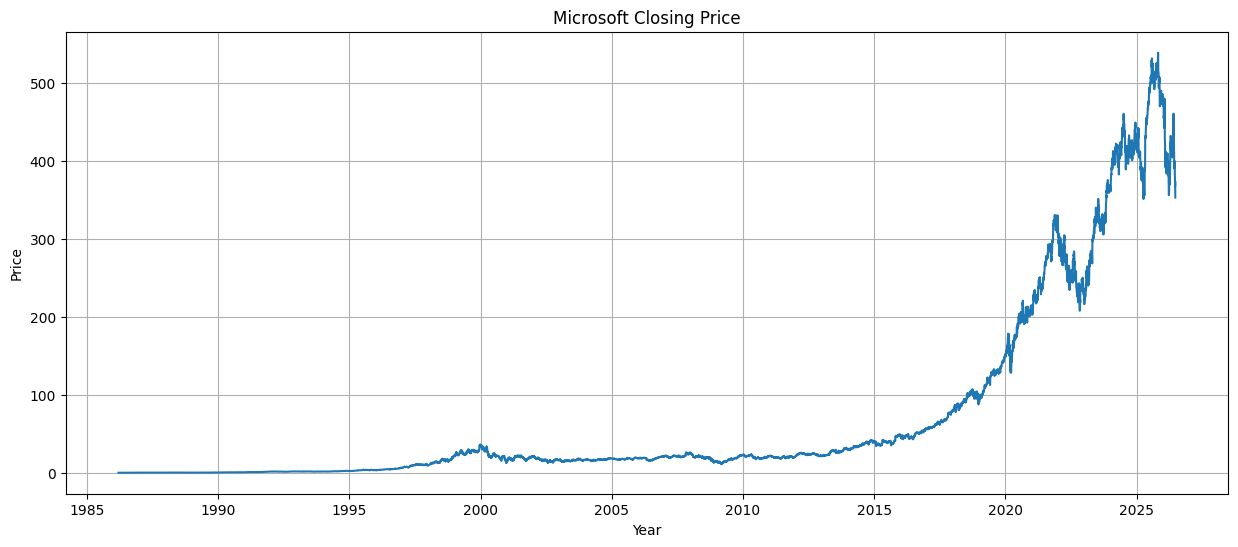

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(df.index, df["Close"])

plt.title("Microsoft Closing Price")

plt.xlabel("Year")

plt.ylabel("Price")

plt.grid(True)

plt.show()

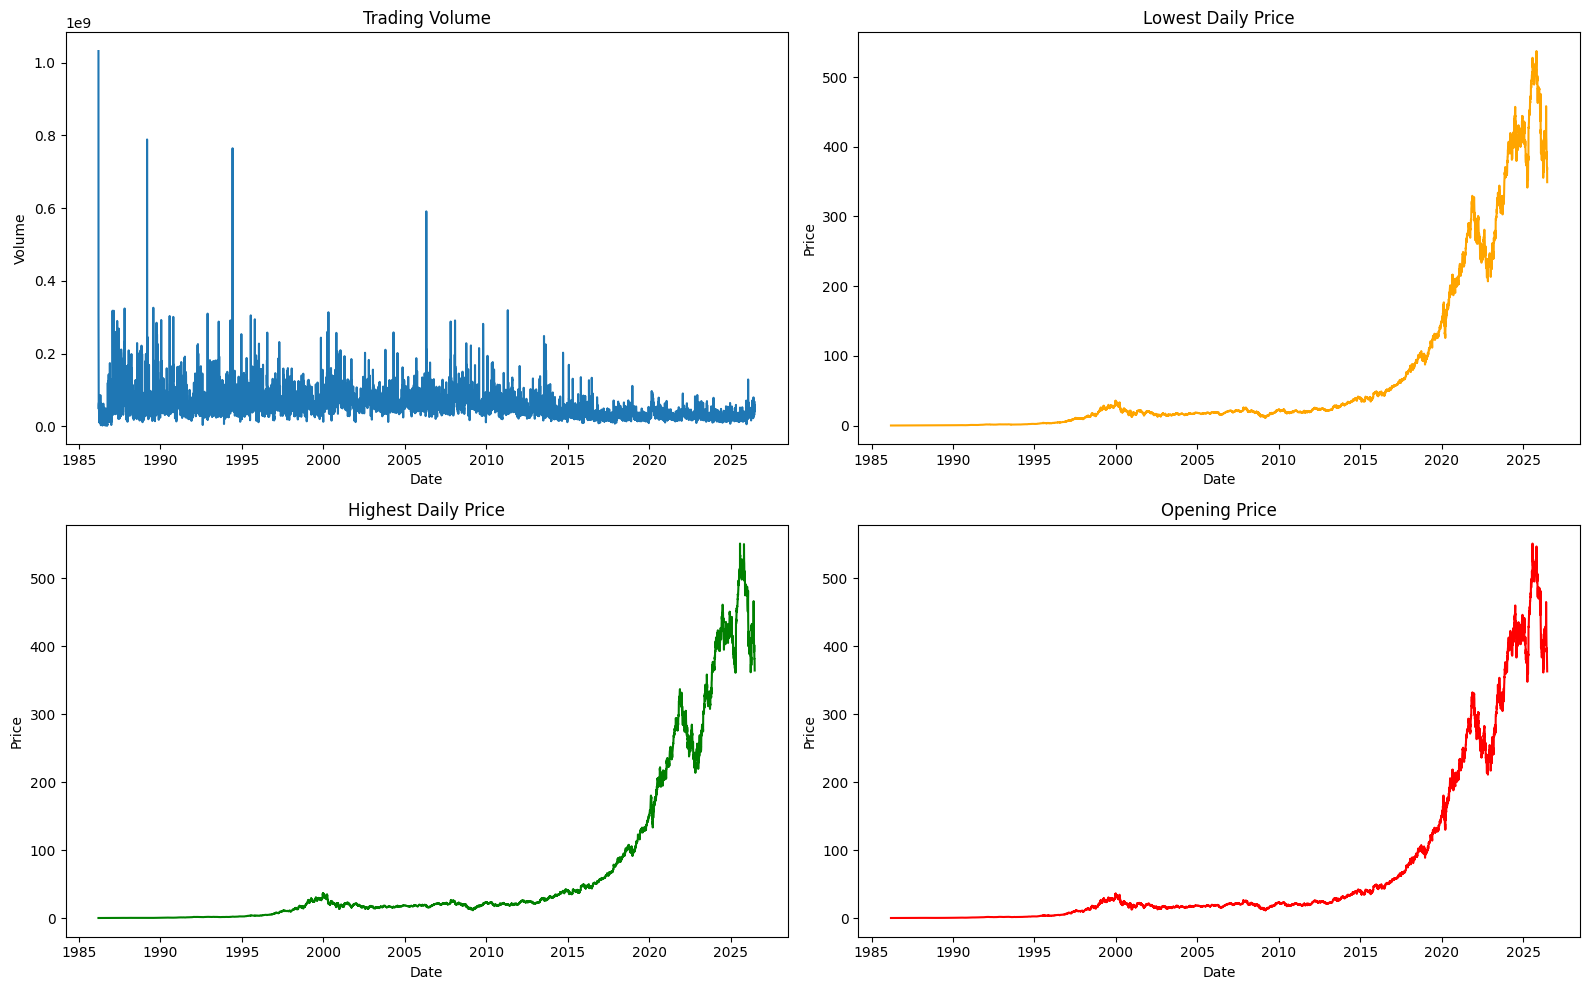

In [18]:
import matplotlib.pyplot as plt

# Create a figure with 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Trading Volume
axes[0, 0].plot(df.index, df["Volume"])
axes[0, 0].set_title("Trading Volume")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("Volume")

# Lowest Daily Price
axes[0, 1].plot(df.index, df["Low"], color="orange")
axes[0, 1].set_title("Lowest Daily Price")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Price")

# Highest Daily Price
axes[1, 0].plot(df.index, df["High"], color="green")
axes[1, 0].set_title("Highest Daily Price")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Price")

# Opening Price
axes[1, 1].plot(df.index, df["Open"], color="red")
axes[1, 1].set_title("Opening Price")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Price")

# Adjust spacing between plots
plt.tight_layout()

# Display all graphs in one canvas
plt.show()

 Analysis:
- Trading volume shows occasional sharp spikes, indicating periods of high market activity.
- Open, High, and Low prices follow a very similar upward trend over time, reflecting strong long-term stock growth.
- Price volatility increases significantly in recent years, with larger fluctuations compared to earlier periods.
- Overall, the stock has experienced substantial appreciation despite short-term market corrections.

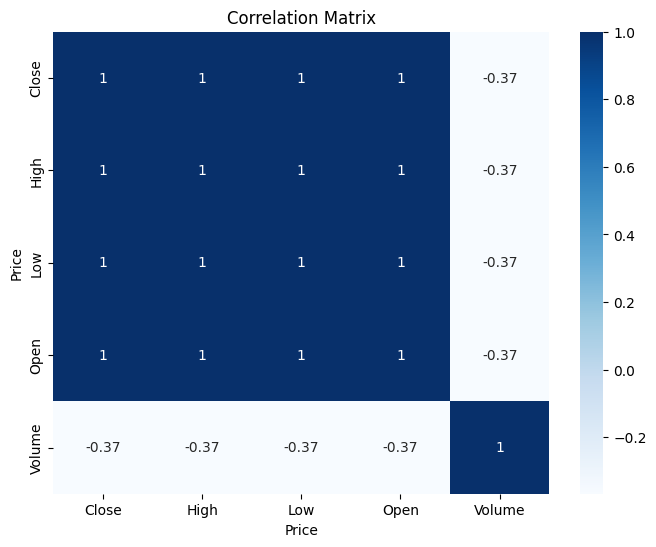

In [19]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

Observation:
- Price-related features (Open, High, Low, Close) are highly positively correlated,
- while Volume has a moderate negative correlation with prices.
- This indicates that stock prices move together, whereas trading volume follows a different pattern.

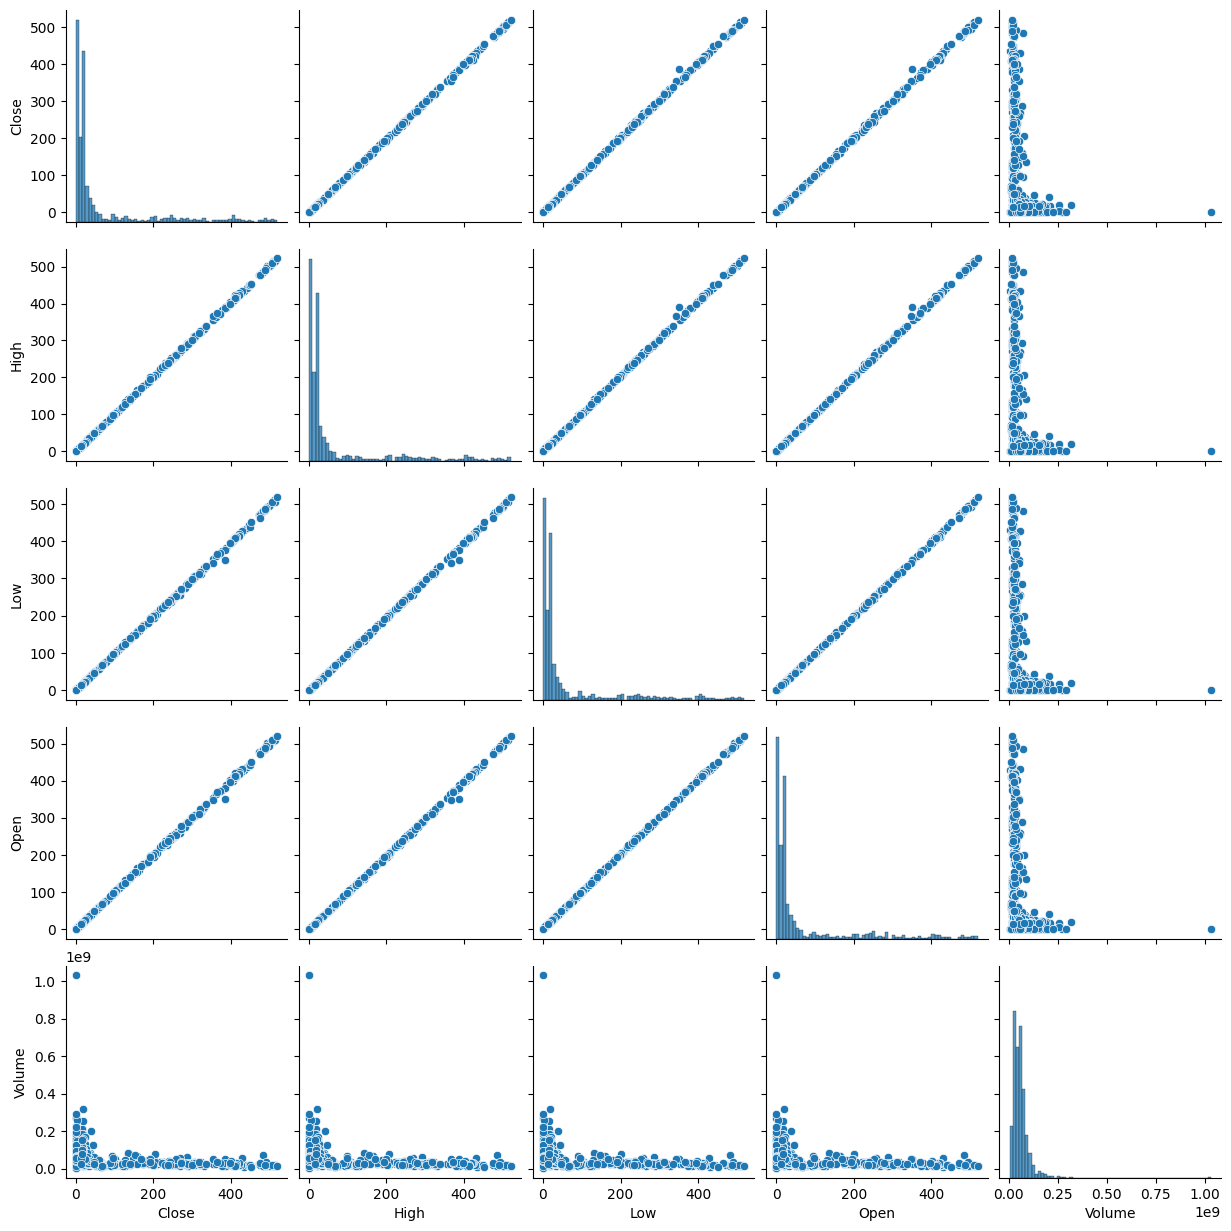

In [20]:
sns.pairplot(df.sample(1000, random_state=42))

boxplot is not applicable for this stock analysis because the outliers that appear in boxlot are not my mistake or errors those points represent real stock price movements. (like civis-19 ,AI boom, financial crises, etc)

## Step 7 - Feature Engineering

In [21]:
df["Daily_Range"] = df["High"] - df["Low"]                # Daily Range
 # This tells how much the stock moved during the day.

In [22]:
#df["Daily_Change"] = df["Close"] - df["Open"]             # Daily Change
# Difference between opening and closing price.

In [23]:
df["MA_10"] = df["Close"].rolling(window=10).mean()   # 10-Day Moving Average

In [24]:
df["MA_50"] = df["Close"].rolling(window=50).mean()     # 50-Day Moving Average

In [25]:
df

Price,Close,High,Low,Open,Volume,Daily_Range,MA_10,MA_50
Date,,,,,,,,
1986-03-13,0.059125,0.061765,0.053847,0.053847,1031788800,0.007919,NaN,NaN
1986-03-14,0.061237,0.062293,0.059125,0.059125,308160000,0.003168,NaN,NaN
1986-03-17,0.062293,0.062821,0.061237,0.061237,133171200,0.001584,NaN,NaN
1986-03-18,0.060709,0.062821,0.060181,0.062293,67766400,0.002640,NaN,NaN
1986-03-19,0.059653,0.061237,0.059125,0.060709,47894400,0.002111,NaN,NaN
...,...,...,...,...,...,...,...,...
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,8.089996,396.215997,412.440434
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,14.559998,391.282996,412.341959
2026-06-23,373.940002,377.220001,370.670013,372.380005,40647600,6.549988,387.502997,412.419390


you will notice the first few rows contain NaN values because moving averages need previous data.

In [26]:
df.dropna(inplace=True)         # drop rows with NaN values, which are created due to the moving averages.
df

Price,Close,High,Low,Open,Volume,Daily_Range,MA_10,MA_50
Date,,,,,,,,
1986-05-22,0.065460,0.065988,0.065460,0.065460,4406400,0.000528,0.067044,0.062921
1986-05-23,0.065460,0.066516,0.065460,0.065460,4089600,0.001056,0.066886,0.063048
1986-05-27,0.067572,0.067572,0.065460,0.065460,13881600,0.002111,0.066886,0.063174
1986-05-28,0.069683,0.069683,0.067572,0.067572,15523200,0.002111,0.067044,0.063322
1986-05-29,0.071268,0.072323,0.069156,0.069683,45676800,0.003168,0.067414,0.063533
...,...,...,...,...,...,...,...,...
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,8.089996,396.215997,412.440434
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,14.559998,391.282996,412.341959
2026-06-23,373.940002,377.220001,370.670013,372.380005,40647600,6.549988,387.502997,412.419390


## Step 8 - Defining Features and Target

In [27]:
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume",
        "Daily_Range",
        "MA_10",
        "MA_50"
    ]
]

In [28]:
y = df["Close"]        # target (Dependent Variable)

In [29]:
print(X.shape)

print(y.shape)

(10100, 7)
(10100,)


 ## Step 9 - Train/Test Split

In [30]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

 Sequential splitting is used to train on time series data and evaluate the model on future unseen data. (random splitting is not practicle here)

In [31]:
print(X_train.shape)

print(X_test.shape)

(8080, 7)
(2020, 7)


## Step 11 - Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [33]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

## Step 12 - Training Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Prediction

In [35]:
y_pred = model.predict(
    X_test_scaled
)

In [36]:
print(y_test.head())

print(y_pred[:5])

Date
2018-06-12    93.603981
2018-06-13    93.178986
2018-06-14    93.705605
2018-06-15    92.513718
2018-06-18    93.188202
Name: Close, dtype: float64
[93.46870026 93.39683646 93.77692016 92.79956855 92.8423968 ]


In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,93.603981,93.468700
1,93.178986,93.396836
2,93.705605,93.776920
3,92.513718,92.799569
4,93.188202,92.842397
5,93.188202,93.017509
6,94.121376,94.372752
7,93.446907,93.759054
8,92.772430,92.520721
9,90.906090,90.543228


### Evaluation

In [38]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [39]:
# MAE (mean absolute error) is a measure of how far off predictions are from actual values, on average.
# It is the average of the absolute differences between predicted and actual values. A lower MAE indicates better model performance.
mae = mean_absolute_error(
    y_test,
    y_pred
)

print(mae)

1.1747283822182863


On average, our prediction is off by about $1.17.

In [40]:
# MSE (mean squared error) is a measure of how far off predictions are from actual values, on average, but it gives more weight to larger errors.
#  It is the average of the squared differences between predicted and actual values. A lower MSE indicates better model performance.
mse = mean_squared_error(
    y_test,
    y_pred
)

print(mse) 

2.742596351104096


In [41]:
# RMSE (root mean squared error) is a measure of how far off predictions are from actual values, on average, but it gives more weight to larger errors. 
# It is the square root of the mean squared error. A lower RMSE indicates better model performance.
rmse = np.sqrt(mse)

print(rmse)

1.6560786065595123


Your model misses the real price by about +-1.650

In [42]:
#  R-squared (R²) is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model. 
# It provides an indication of goodness of fit and therefore a measure of how well unseen samples are likely to be predicted by the model, through the proportion of explained variance.
r2 = r2_score(
    y_test,
    y_pred
)

print(r2)

0.9998164328659785


99.98% which is good

## STEP 13 — Model Interpretation

In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,Open,-10.283956
1,High,13.546308
2,Low,13.775585
3,Volume,-0.001578
4,Daily_Range,0.004403
5,MA_10,0.204085
6,MA_50,-0.059209


This tells which features influence the prediction the most.

In [44]:
importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
2,Low,13.775585
1,High,13.546308
5,MA_10,0.204085
4,Daily_Range,0.004403
3,Volume,-0.001578
6,MA_50,-0.059209
0,Open,-10.283956


## Step 16 - Visualizing Predictions

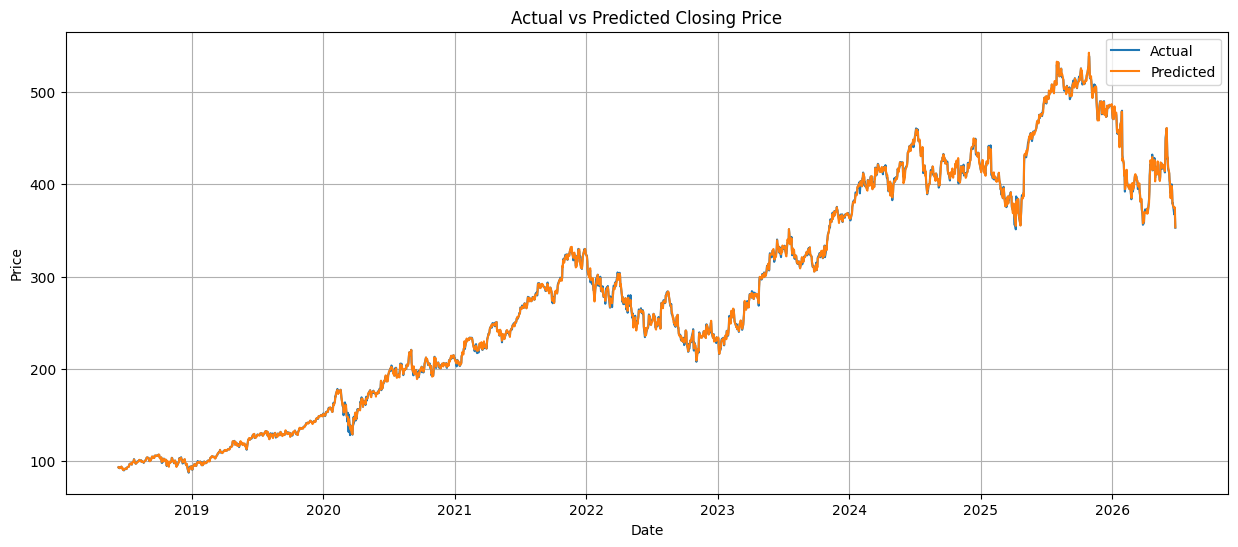

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

## Step 17 - Saving model

In [47]:
import pickle

# Save the trained model
with open("stock_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [ ]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

# s